In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
import sys
import sklearn
import numpy
import scipy

print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Scikit-learn: 1.9.0
NumPy: 2.5.1
SciPy: 1.18.0


In [4]:
import sys
print(sys.executable)

import sys
!{sys.executable} -m pip install --upgrade --force-reinstall numpy scipy scikit-learn

c:\Users\SACHIN\AppData\Local\Python\pythoncore-3.14-64\python.exe
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.ensemble import IsolationForest

In [6]:
df = pd.read_csv("cleaned_rba_dataset.csv")

In [7]:
df.head()

,Record_ID,Login_Timestamp,User_ID,Round_Trip_Time_ms,IP_Address,Country_name,Region,City,Autonomous_System_Number_ASN,User_Agent_String,Browser_Name_and_Version,OS_Name_and_Version,Device_Type,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,0,NaN,-4.320000e+18,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,NaN,-4.320000e+18,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,NaN,-3.280000e+18,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,NaN,-4.320000e+18,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,NaN,-4.620000e+18,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Record_ID                     30001 non-null  int64  
 1   Login_Timestamp               11883 non-null  str    
 2   User_ID                       30001 non-null  float64
 3   Round_Trip_Time_ms            1462 non-null   float64
 4   IP_Address                    30001 non-null  str    
 5   Country_name                  30001 non-null  str    
 6   Region                        29968 non-null  str    
 7   City                          29996 non-null  str    
 8   Autonomous_System_Number_ASN  30001 non-null  int64  
 9   User_Agent_String             30001 non-null  str    
 10  Browser_Name_and_Version      30001 non-null  str    
 11  OS_Name_and_Version           30001 non-null  str    
 12  Device_Type                   29999 non-null  str    
 13  Login_Succes

In [9]:
df.isnull().sum()

Record_ID                           0
Login_Timestamp                 18118
User_ID                             0
Round_Trip_Time_ms              28539
IP_Address                          0
Country_name                        0
Region                             33
City                                5
Autonomous_System_Number_ASN        0
User_Agent_String                   0
Browser_Name_and_Version            0
OS_Name_and_Version                 0
Device_Type                         2
Login_Successful                    0
Is_Attack_IP                        0
Is_Account_Takeover                 0
dtype: int64

In [10]:
#Select Required Features
selected_columns = [
    "Country_name",
    "Region",
    "City",
    "Device_Type",
    "Browser_Name_and_Version",
    "OS_Name_and_Version",
    "Round_Trip_Time_ms",
    "Login_Successful",
    "Is_Attack_IP",
    "Is_Account_Takeover"
]

ml_df = df[selected_columns].copy()

ml_df.head()

,Country_name,Region,City,Device_Type,Browser_Name_and_Version,OS_Name_and_Version,Round_Trip_Time_ms,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,NO,-,-,mobile,Firefox 20.0.0.1618,iOS 13.4,NaN,False,False,False
1,AU,-,-,mobile,Chrome Mobile 46.0.2490,Android 4.1,NaN,False,False,False
2,NO,Vestland,Urangsvag,mobile,Android 2.3.3.2672,iOS 7.1,NaN,True,False,False
3,US,-,-,mobile,Chrome Mobile WebView 85.0.4183,Android 4.1,NaN,False,False,False
4,US,Virginia,Ashburn,mobile,Chrome Mobile WebView 85.0.4183,Android 2.2,NaN,False,True,False


In [11]:
# Encode Categorical Features
# Create Label Encoder
encoder = LabelEncoder()

# List of Categorical Columns
categorical_columns = [
    "Country_name",
    "Region",
    "City",
    "Device_Type",
    "Browser_Name_and_Version",
    "OS_Name_and_Version"
]

In [12]:
# # Convert Text into Numbers
for column in categorical_columns:
    ml_df[column] = encoder.fit_transform(ml_df[column])


# Check Encoded Data
ml_df.head()



,Country_name,Region,City,Device_Type,Browser_Name_and_Version,OS_Name_and_Version,Round_Trip_Time_ms,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,82,0,0,2,264,118,NaN,False,False,False
1,5,0,0,2,136,12,NaN,False,False,False
2,82,342,1441,2,20,138,NaN,True,False,False
3,106,0,0,2,240,12,NaN,False,False,False
4,106,347,69,2,240,9,NaN,False,True,False


In [13]:
# Verify Data Types
ml_df.dtypes

Country_name                  int64
Region                        int64
City                          int64
Device_Type                   int64
Browser_Name_and_Version      int64
OS_Name_and_Version           int64
Round_Trip_Time_ms          float64
Login_Successful               bool
Is_Attack_IP                   bool
Is_Account_Takeover            bool
dtype: object

In [14]:
print(ml_df.select_dtypes(include="object").columns)

Index([], dtype='str')


In [15]:
# Train the Isolation Forest Model
# Create the model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

print("Isolation Forest Model Created Successfully!")

Isolation Forest Model Created Successfully!


In [16]:
#Train the Model
model.fit(ml_df)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [17]:
# Predict Anomalies
predictions = model.predict(ml_df)

predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [18]:
# Add Predictions to Dataset
df["Prediction"] = predictions

df.head()

,Record_ID,Login_Timestamp,User_ID,Round_Trip_Time_ms,IP_Address,Country_name,Region,City,Autonomous_System_Number_ASN,User_Agent_String,Browser_Name_and_Version,OS_Name_and_Version,Device_Type,Login_Successful,Is_Attack_IP,Is_Account_Takeover,Prediction
0,0,NaN,-4.320000e+18,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False,1
1,1,NaN,-4.320000e+18,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False,1
2,2,NaN,-3.280000e+18,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False,1
3,3,NaN,-4.320000e+18,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False,1
4,4,NaN,-4.620000e+18,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False,1


In [19]:
# Create Threat Status
df["Threat_Status"] = df["Prediction"].map({
    1: "Normal",
    -1: "Suspicious"
})

# Check the results:

df[["Prediction", "Threat_Status"]].head(10)

,Prediction,Threat_Status
0,1,Normal
1,1,Normal
2,1,Normal
3,1,Normal
4,1,Normal
5,1,Normal
6,1,Normal
7,1,Normal
8,1,Normal
9,1,Normal


In [20]:
# Count Threats
df["Threat_Status"].value_counts()

Threat_Status
Normal        28503
Suspicious     1498
Name: count, dtype: int64

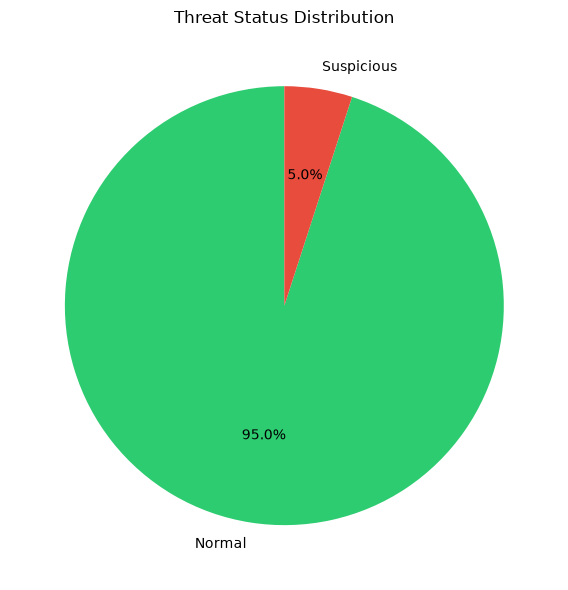

In [21]:
# Visualize Threat Status
import matplotlib.pyplot as plt

threat_counts = df["Threat_Status"].value_counts()

plt.figure(figsize=(6,6))

threat_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#2ECC71", "#E74C3C"],
    startangle=90
)

plt.title("Threat Status Distribution")

plt.ylabel("")

plt.tight_layout()

plt.show()

In [22]:
# View Suspicious Records
suspicious_records = df[df["Threat_Status"] == "Suspicious"]

suspicious_records.head(10)

,Record_ID,Login_Timestamp,User_ID,Round_Trip_Time_ms,IP_Address,Country_name,Region,City,Autonomous_System_Number_ASN,User_Agent_String,Browser_Name_and_Version,OS_Name_and_Version,Device_Type,Login_Successful,Is_Attack_IP,Is_Account_Takeover,Prediction,Threat_Status
51,51,NaN,5.020000e+18,476.0,84.234.159.249,NO,Oslo County,Oslo,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,tablet,False,False,False,-1,Suspicious
60,60,NaN,-6.620000e+18,NaN,170.82.7.240,BR,Sao Paulo,Artur Nogueira,266433,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.19,Mac OS X 10.14.6,desktop,False,True,False,-1,Suspicious
76,76,NaN,9.010000e+18,467.0,51.175.159.252,NO,Oslo County,Oslo,29695,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome 69.0.3497.17.19,Android 4.1,tablet,True,False,False,-1,Suspicious
81,81,NaN,-4.320000e+18,NaN,103.20.90.20,ID,East Java,Surabaya,58381,Opera/9.80 (iPhone; CPU iPhone OS 10_0_1 like...,Opera Mini 19.0.2254,iOS 10.0.1,mobile,False,False,False,-1,Suspicious
89,89,NaN,4.940000e+17,NaN,37.148.220.204,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,True,True,False,-1,Suspicious
180,180,NaN,-4.320000e+18,NaN,10.0.3.72,RO,Buzau,Rusetu,500039,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_6_3...,Chrome 72.0.3626.115,Mac OS X 11.6.3,desktop,False,True,False,-1,Suspicious
194,194,NaN,-4.320000e+18,NaN,151.236.47.206,GB,England,Reading,29550,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...,Chrome 72.0.3626.90,Mac OS X 10.9.4,desktop,False,False,False,-1,Suspicious
215,215,NaN,-4.320000e+18,NaN,79.161.71.15,NO,Vestland,Stord,29695,Opera/9.80 (iPhone; CPU iPhone OS 11_2_2 like...,Opera Mini 20.0.2254,iOS 11.2.2,tablet,False,False,False,-1,Suspicious
217,217,NaN,-4.320000e+18,NaN,77.106.130.37,NO,Innlandet,Loten,29492,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,tablet,False,False,False,-1,Suspicious
240,240,NaN,-4.320000e+18,NaN,194.152.35.141,RU,Moscow,Moscow,47655,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.28,Mac OS X 10.14.6,desktop,False,True,False,-1,Suspicious


In [23]:
# Save Final Dataset
df.to_csv("ml_predictions.csv", index=False)

print("Machine Learning Completed Successfully!")
print("Final dataset saved as: ml_predictions.csv")

Machine Learning Completed Successfully!
Final dataset saved as: ml_predictions.csv


In [24]:
print(df.shape)
print(df[['Prediction', 'Is_Attack_IP']].head())

saved_df = pd.read_csv("ml_predictions.csv")
print(saved_df.shape)
print(saved_df[['Prediction', 'Is_Attack_IP']].head())

(30001, 18)
   Prediction  Is_Attack_IP
0           1         False
1           1         False
2           1         False
3           1         False
4           1          True
(30001, 18)
   Prediction  Is_Attack_IP
0           1         False
1           1         False
2           1         False
3           1         False
4           1          True


In [25]:
print("Dataset Shape :",saved_df.shape)

Dataset Shape : (30001, 18)


In [26]:
print(df['Is_Attack_IP'].unique())
print(df['Prediction'].unique())

[False  True]
[ 1 -1]


In [27]:
y_true = df['Is_Attack_IP'].map({'Yes':1, 'No':0})
y_pred = df['Prediction'].map({-1:1, 1:0})

In [28]:
print(df['Is_Attack_IP'].isnull().sum())

0


In [29]:
print(df['Is_Attack_IP'].unique())

[False  True]


In [30]:
# Remove rows with missing labels
df_eval = df.dropna(subset=['Is_Attack_IP']).copy()

y_true = df_eval['Is_Attack_IP'].astype(int)
y_pred = df_eval['Prediction'].map({-1: 1, 1: 0})

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 89.31035632145596


In [31]:
display(df[['Record_ID', 'User_ID', 'Prediction']].head(200))

,Record_ID,User_ID,Prediction
0,0,-4.320000e+18,1
1,1,-4.320000e+18,1
2,2,-3.280000e+18,1
3,3,-4.320000e+18,1
4,4,-4.620000e+18,1
...,...,...,...
195,195,-7.320000e+18,1
196,196,9.190000e+18,1
197,197,-4.320000e+18,1
198,198,-4.320000e+18,1


In [32]:
print(df['Prediction'].value_counts())
print(df['Prediction'].unique())

Prediction
 1    28503
-1     1498
Name: count, dtype: int64
[ 1 -1]


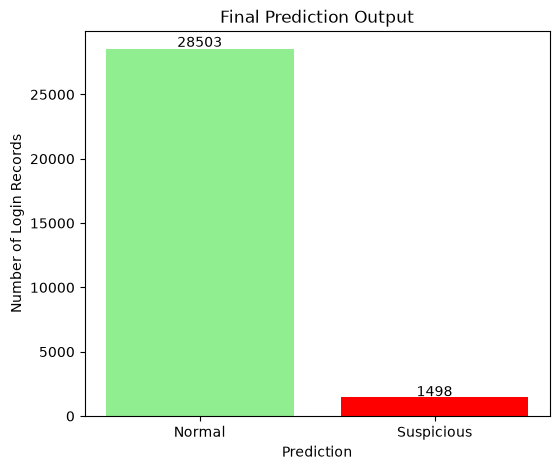

In [33]:
import matplotlib.pyplot as plt

normal = (df['Prediction'] == 1).sum()
anomaly = (df['Prediction'] == -1).sum()

plt.figure(figsize=(6,5))
plt.bar(['Normal', 'Suspicious'], [normal, anomaly], color=['lightgreen', 'red'])

plt.title("Final Prediction Output")
plt.xlabel("Prediction")
plt.ylabel("Number of Login Records")

plt.text(0, normal + 200, str(normal), ha='center')
plt.text(1, anomaly + 50, str(anomaly), ha='center')

plt.show()

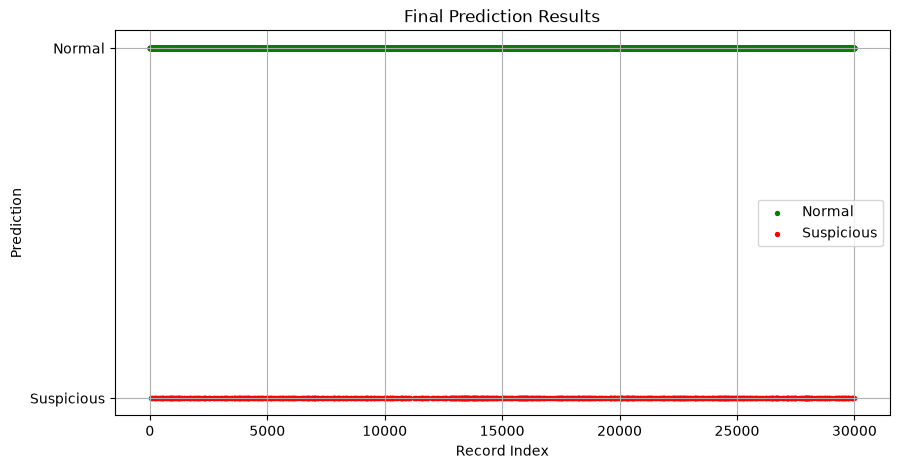

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Normal Logins
plt.scatter(
    df[df['Prediction'] == 1].index,
    df[df['Prediction'] == 1]['Prediction'],
    color='green',
    s=8,
    label='Normal'
)

# Suspicious Logins
plt.scatter(
    df[df['Prediction'] == -1].index,
    df[df['Prediction'] == -1]['Prediction'],
    color='red',
    s=8,
    label='Suspicious'
)

plt.title("Final Prediction Results")
plt.xlabel("Record Index")
plt.ylabel("Prediction")
plt.yticks([-1, 1], ["Suspicious", "Normal"])
plt.legend()
plt.grid(True)

plt.show()